# 2D Multi-Temperature ML Model: $(q, T) \to U_{\mathrm{eff}}$

This notebook extends the 1D single-temperature model (`MSci-1D-ML-Notebook`) to a unified multi-temperature architecture. Rather than training separate networks at each temperature, a single network is trained on data pooled across all 10 temperatures, taking the joint input $(q, T)$ and outputting $U_{\mathrm{eff}}$.

## Data

Reference data $U_{\mathrm{eff}}^{\mathrm{num}}$ is generated by the same numerical solver as in Notebook 2 ($U_{\mathrm{eff}}(0,\beta)=0$, atomic units), using 10 log-spaced temperatures $T \in [0.1, 10]$. The solver grid is trimmed by one unit at each edge to remove finite-difference boundary errors:

| Potential | Solver grid | ML region | Positions (post-trim) | Total points (post-trim) |
|-----------|-------------|-----------|-----------|--------------|
| QHO | $[-10, 10]$ | $(-9, 9)$ | 180 | 1800 |
| Quartic | $[-8, 8]$ | $(-7, 7)$ | 174 | 1740 |
| Morse | $[-2, 10]$ | $(-1, 9)$ | 166 | 1660 |

**Train/Validation/Test split:** 10 position indices per temperature are held out for validation and 10 for testing, with the same indices withheld at every temperature so all three sets span all temperatures.

| Potential | Train | Validation | Test |
|-----------|-------|------------|------|
| QHO | 1600 | 100 | 100 |
| Quartic | 1540 | 100 | 100 |
| Morse | 1460 | 100 | 100 |

## Model

Each model $\mathrm{NN}_\theta : (q, T) \mapsto U_{\mathrm{eff}}(q, T)$ is a feedforward network with two hidden layers of 64 neurons (wider than the 32-neuron 1D model, accommodating the larger dataset and additional temperature input) and $\tanh$ activations. Weights are Xavier-uniform initialised and optimised with AdamW ($\eta = 10^{-3}$, weight decay $10^{-3}$) using unweighted MSE loss with validation-based early stopping:

$$\mathcal{L}(\theta) = \frac{1}{N_{\mathrm{train}}} \sum_{i=1}^{N_{\mathrm{train}}} \left[ \mathrm{NN}_\theta(q_i, T_i) - U_{\mathrm{eff}}^{\mathrm{num}}(q_i, T_i) \right]^2$$

The relative test RMSE $\varepsilon_{\mathrm{rel}}^{\mathrm{test}} = \mathrm{RMSE}_{\mathrm{test}} / \sigma_{\mathrm{test}}$ normalises against the standard deviation of $U_{\mathrm{eff}}$ on the test set, consistent with the 1D notebook. Full analysis (learning curves and temperature extrapolation) is performed on the QHO; prediction quality only is reported for the quartic and Morse potentials.

In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import copy

## Numerical Solver:  `QuantumSystem1D`


In [2]:
class QuantumSystem1D:
    """
    Lean quantum solver: diagonalises the 1D Hamiltonian and computes
    the effective potential U_eff(q, β) from the thermal density matrix.

    Uses atomic units: ℏ = m = ω = k_B = 1.
    """

    def __init__(self, V, qmin, qmax, n_points, m=1.0, ℏ=1.0):
        self.V = V
        self.qmin = qmin
        self.qmax = qmax
        self.n_points = n_points
        self.m = m
        self.ℏ = ℏ
        self.q_grid = np.linspace(qmin, qmax, n_points)
        self.q_delta = self.q_grid[1] - self.q_grid[0]
        self._solve_eigenproblem()

    def _solve_eigenproblem(self):
        """Construct and diagonalise the Hamiltonian (finite-difference discretisation)."""
        H = np.zeros((self.n_points, self.n_points))
        kinetic_diag = self.ℏ**2 / (self.m * self.q_delta**2)
        kinetic_off  = -self.ℏ**2 / (2.0 * self.m * self.q_delta**2)

        for i in range(self.n_points):
            for j in range(self.n_points):
                if i == j:
                    H[i, j] = kinetic_diag + self.V(self.q_grid[i])[0]
                elif abs(i - j) == 1:
                    H[i, j] = kinetic_off

        eigenvalues, eigenvectors = np.linalg.eigh(H)
        eigenvectors = eigenvectors.T
        for i in range(len(eigenvectors)):
            norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))
            eigenvectors[i] /= norm

        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        print(f"Solved: {self.n_points} states, E₀ = {eigenvalues[0]:.6f}, E₁ = {eigenvalues[1]:.6f}")

    def thermal_density_diagonal(self, β):
        """⟨q|e^{-βH}|q⟩ = Σₙ |ψₙ(q)|² e^{-β Eₙ}"""
        ρ = np.zeros_like(self.q_grid)
        for E, ψ in zip(self.eigenvalues, self.eigenvectors):
            ρ += ψ**2 * np.exp(-β * E)
        return ρ

    def effective_potential_quantum(self, β):
        """U_eff(q, β) = -(1/β) ln ρ(q,q;β), pinned so U_eff(0) = 0."""
        ρ = self.thermal_density_diagonal(β)
        U = -(1.0 / β) * np.log(np.maximum(ρ, 1e-300))
        q0_idx = np.argmin(np.abs(self.q_grid))
        return U - U[q0_idx]


## Potentials

In [3]:
def V_harmonic(q):
    return 0.5 * q**2, q, 1.0

def V_quartic(q, k=1.0, lam=0.1):
    V   = 0.5 * k * q**2 + 0.25 * lam * q**4
    dV  = k * q + lam * q**3
    d2V = k + 3 * lam * q**2
    return V, dV, d2V

def V_morse(q, D_e=10.0, a=1.0, q_e=0.0):
    e   = np.exp(-a * (q - q_e))
    V   = D_e * (1 - e)**2
    dV  = 2 * D_e * a * e * (1 - e)
    d2V = 2 * D_e * a**2 * e * (2*e - 1)
    return V, dV, d2V

systems = {
    'QHO':     QuantumSystem1D(V=V_harmonic, qmin=-10, qmax=10, n_points=200),
    'Quartic': QuantumSystem1D(V=lambda q: V_quartic(q, k=1.0, lam=0.1), qmin=-8, qmax=8, n_points=200),
    'Morse':   QuantumSystem1D(V=lambda q: V_morse(q, D_e=10.0, a=1.0, q_e=0.0), qmin=-2, qmax=10, n_points=200),
}


Solved: 200 states, E₀ = 0.499684, E₁ = 1.498420
Solved: 200 states, E₀ = 0.517139, E₁ = 1.582396
Solved: 200 states, E₀ = 2.109122, E₁ = 5.577158


/tmp/ipykernel_2891/2247742118.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(eigenvectors[i]**2, self.q_grid))


## Dataset Generation

In [4]:
n_temperatures = 10
temperatures   = np.logspace(np.log10(0.1), np.log10(10.0), n_temperatures)

# trim one unit from each edge of the solver grid to remove boundary errors
trim_bounds = {
    'QHO':     (-9,  9),
    'Quartic': (-7,  7),
    'Morse':   (-1,  9),
}

datasets = {}
for name, sys in systems.items():
    q_grid_full = sys.q_grid.copy()
    n_pos_full  = len(q_grid_full)
    U_eff_full  = np.zeros((n_temperatures, n_pos_full))
    for i, T in enumerate(temperatures):
        U_eff_full[i] = sys.effective_potential_quantum(1.0 / T)

    qlo, qhi = trim_bounds[name]
    mask     = (q_grid_full > qlo) & (q_grid_full < qhi)
    q_grid   = q_grid_full[mask]
    U_eff    = U_eff_full[:, mask]
    n_pos    = len(q_grid)
    sigma_U  = np.array([np.std(U_eff[i]) for i in range(n_temperatures)])
    datasets[name] = {'q_grid': q_grid, 'U_eff': U_eff, 'sigma_U': sigma_U, 'n_pos': n_pos}
    print(f"{name}: {n_temperatures} T x {n_pos} positions (trimmed to ({qlo}, {qhi}))")


QHO: 10 T x 180 positions (trimmed to (-9, 9))
Quartic: 10 T x 174 positions (trimmed to (-7, 7))
Morse: 10 T x 166 positions (trimmed to (-1, 9))


## Model Architecture and Training

In [5]:
def build_model(hidden_dims=[64, 64]):
    layers = []
    d_in = 2
    for d_h in hidden_dims:
        layers.append(nn.Linear(d_in, d_h))
        layers.append(nn.Tanh())
        d_in = d_h
    layers.append(nn.Linear(d_in, 1))
    model = nn.Sequential(*layers)
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    return model

def train_2d(model, X_train, y_train, X_val, y_val, epochs, lr):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    best_val, best_state = float('inf'), None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = nn.functional.mse_loss(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            vl = nn.functional.mse_loss(model(X_val), y_val).item()
        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model

def compute_rmse(model, X, y_np):
    model.eval()
    with torch.no_grad():
        pred = model(X).numpy()
    return np.sqrt(np.mean((pred - y_np)**2))


## QHO: Full Analysis

In [6]:
hidden_dims = [64, 64]
epochs, lr, seed = 3000, 0.001, 1

training_fractions = [0.05, 0.10, 0.20, 0.25, 0.40, 0.50, 0.75, 0.80, 1.00]
n_fracs = len(training_fractions)
n_test_per_T, n_val_per_T = 10, 10

def prepare_and_train(ds, name):
    q_grid, U_eff, sigma_U, n_pos = ds['q_grid'], ds['U_eff'], ds['sigma_U'], ds['n_pos']
    rng       = np.random.default_rng(seed=seed)
    idx_shuf  = rng.permutation(n_pos)
    test_pos  = set(idx_shuf[:n_test_per_T])
    val_pos   = set(idx_shuf[n_test_per_T:n_test_per_T + n_val_per_T])

    all_q = np.tile(q_grid, n_temperatures)
    all_T = np.repeat(temperatures, n_pos)
    all_U = U_eff.flatten()
    j_idx = np.tile(np.arange(n_pos), n_temperatures)

    is_test  = np.isin(j_idx, list(test_pos))
    is_val   = np.isin(j_idx, list(val_pos))
    is_train = ~is_test & ~is_val

    X_all      = np.column_stack([all_q, all_T])
    sigma_test = np.std(all_U[is_test])

    Xv = torch.tensor(X_all[is_val],                dtype=torch.float32)
    yv = torch.tensor(all_U[is_val].reshape(-1, 1), dtype=torch.float32)
    Xte = torch.tensor(X_all[is_test],              dtype=torch.float32)

    X_tr_full = X_all[is_train]
    y_tr_full = all_U[is_train].reshape(-1, 1)
    n_train_total = len(X_tr_full)
    shuf = np.random.default_rng(seed=seed).permutation(n_train_total)
    X_tr_s, y_tr_s = X_tr_full[shuf], y_tr_full[shuf]

    rmse_arr   = np.zeros(n_fracs)
    rel_arr    = np.zeros(n_fracs)
    ntrain_arr = np.zeros(n_fracs, dtype=int)
    best_model = None

    for f_idx, frac in enumerate(training_fractions):
        n_train = max(1, int(n_train_total * frac))
        Xt = torch.tensor(X_tr_s[:n_train], dtype=torch.float32)
        yt = torch.tensor(y_tr_s[:n_train], dtype=torch.float32)
        model = build_model(hidden_dims)
        model = train_2d(model, Xt, yt, Xv, yv, epochs, lr)
        rmse_arr[f_idx]   = compute_rmse(model, Xte, all_U[is_test].reshape(-1, 1))
        rel_arr[f_idx]    = rmse_arr[f_idx] / sigma_test
        ntrain_arr[f_idx] = n_train
        if frac == 1.0: best_model = model
        print(f"  {name} {frac*100:5.0f}%: n={n_train:4d}  ε_rel^test={rel_arr[f_idx]:.4f}")

    return best_model, rmse_arr, rel_arr, ntrain_arr, {
        'all_q': all_q, 'all_T': all_T, 'all_U': all_U,
        'X_all': X_all, 'is_test': is_test, 'sigma_U': sigma_U, 'sigma_test': sigma_test,
        'q_grid': q_grid, 'U_eff': U_eff
    }

print("=== QHO ===")
qho_model, qho_rmse, qho_rel, qho_ntrain, qho_info = prepare_and_train(datasets['QHO'], 'QHO')


=== QHO ===
  QHO     5%: n=  80  ε_rel^test=0.0554
  QHO    10%: n= 160  ε_rel^test=0.0238
  QHO    20%: n= 320  ε_rel^test=0.0242
  QHO    25%: n= 400  ε_rel^test=0.0190
  QHO    40%: n= 640  ε_rel^test=0.0188
  QHO    50%: n= 800  ε_rel^test=0.0192
  QHO    75%: n=1200  ε_rel^test=0.0170
  QHO    80%: n=1280  ε_rel^test=0.0171
  QHO   100%: n=1600  ε_rel^test=0.0154


### Predictions at Each Temperature

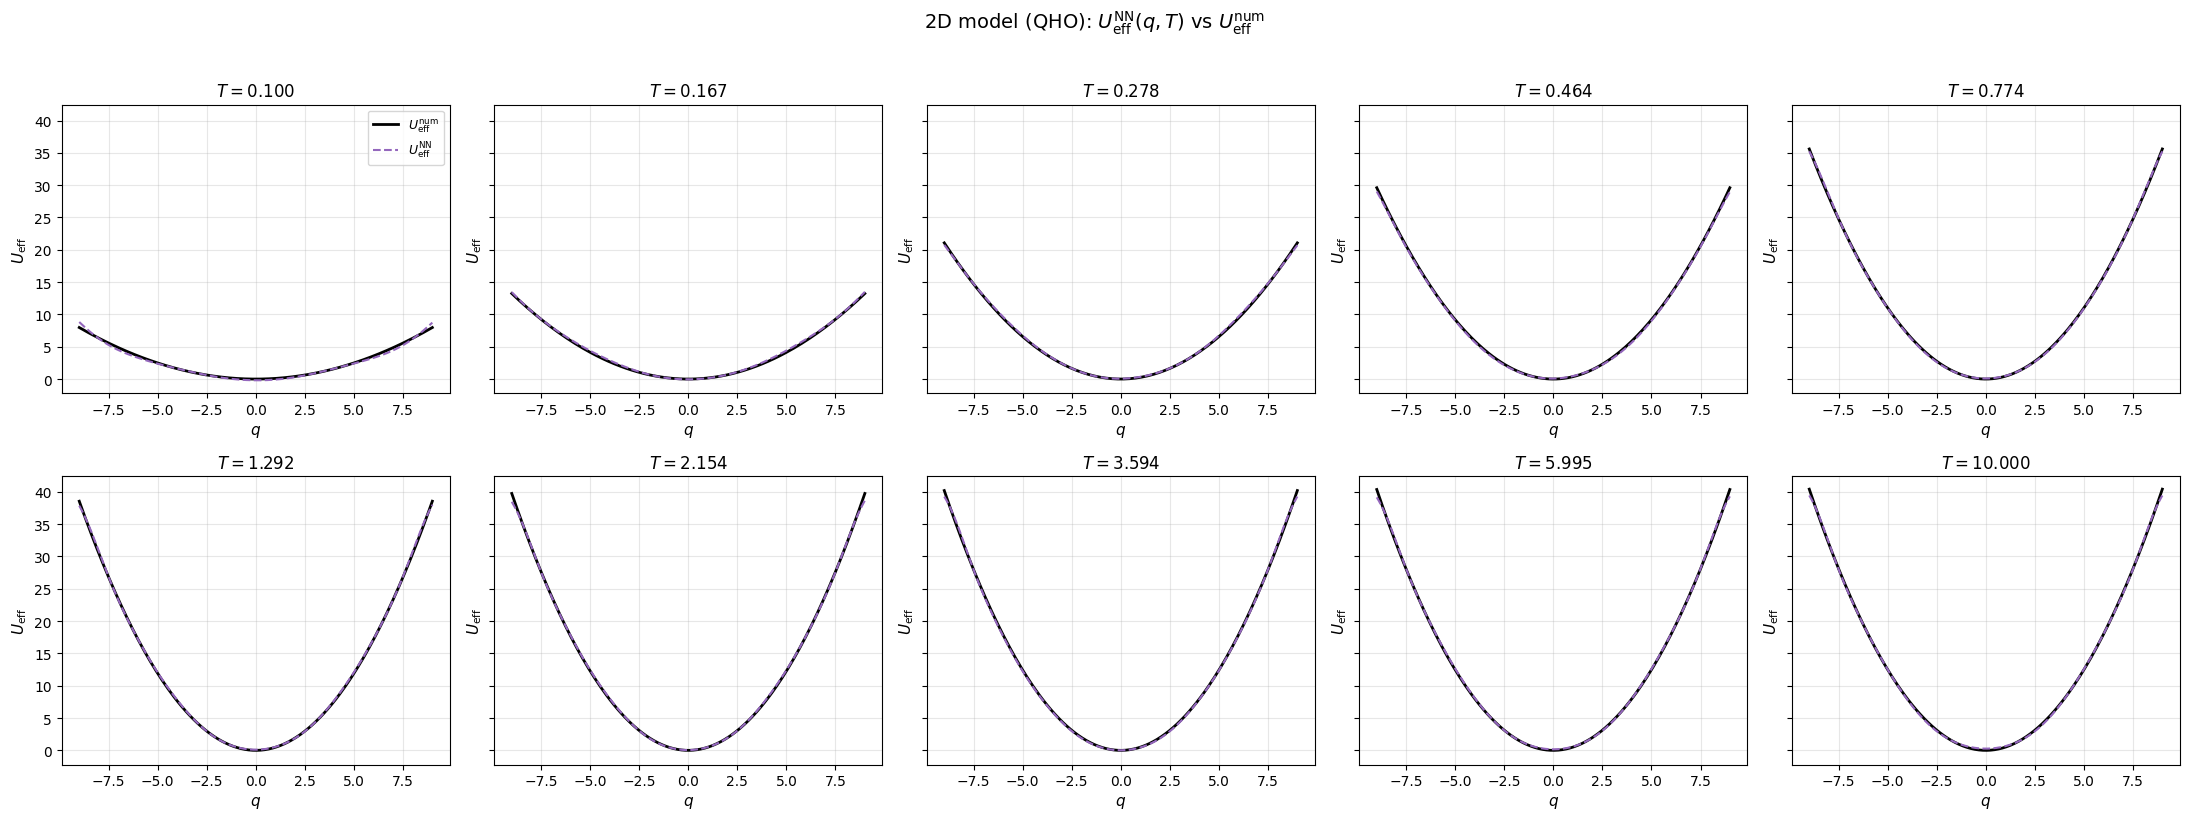

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
qho_model.eval()
q_dense = np.linspace(qho_info['q_grid'].min(), qho_info['q_grid'].max(), 500)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    X_p = np.column_stack([q_dense, np.full_like(q_dense, T)])
    with torch.no_grad():
        y_pred = qho_model(torch.tensor(X_p, dtype=torch.float32)).numpy().flatten()
    ax.plot(qho_info['q_grid'], qho_info['U_eff'][idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense, y_pred, '--', lw=1.5, color='tab:purple', label=r'$U_{\mathrm{eff}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'2D model (QHO): $U_{\mathrm{eff}}^{\mathrm{NN}}(q,T)$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$',
             fontsize=14, y=1.02)
plt.tight_layout()
from google.colab import files
plt.savefig('2D-QHO-predictions.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-QHO-predictions.pdf')

### Per-Temperature Relative Error

The relative RMSE $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T) = \mathrm{RMSE}_{\mathrm{test}}(T) / \sigma_{\mathrm{test}}$ is evaluated on the test set at each temperature.

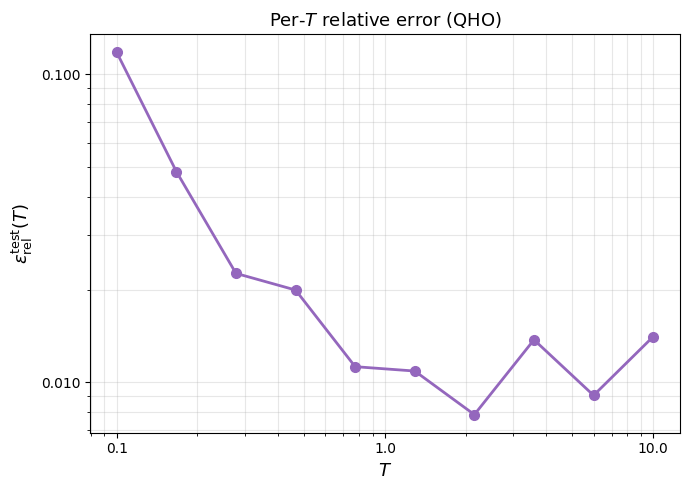

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         T    ε_rel^test
    0.1000      0.117783
    0.1668      0.048360
    0.2783      0.022586
    0.4642      0.019941
    0.7743      0.011244
    1.2915      0.010883
    2.1544      0.007858
    3.5938      0.013750
    5.9948      0.009073
   10.0000      0.014075


In [8]:
qho_model.eval()
per_T_rmse = np.zeros(n_temperatures)
for t_idx, T in enumerate(temperatures):
    mask = qho_info['is_test'] & (qho_info['all_T'] == T)
    Xt_ = torch.tensor(qho_info['X_all'][mask], dtype=torch.float32)
    yt_ = qho_info['all_U'][mask].reshape(-1, 1)
    per_T_rmse[t_idx] = compute_rmse(qho_model, Xt_, yt_)

per_T_sigma = np.array([
    np.std(qho_info['all_U'][qho_info['is_test'] & (qho_info['all_T'] == T)])
    for T in temperatures
])
per_T_rel_test = per_T_rmse / per_T_sigma

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(temperatures, per_T_rel_test, 'o-', color='tab:purple', lw=2, ms=7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$T$', fontsize=13)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}(T)$', fontsize=13)
ax.set_title(r'Per-$T$ relative error (QHO)', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
from google.colab import files
plt.savefig('2D-QHO-error-vs-T.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-QHO-error-vs-T.pdf')

print(f"{'T':>10}  {'ε_rel^test':>12}")
for T, e in zip(temperatures, per_T_rel_test):
    print(f"{T:10.4f}  {e:12.6f}")


### Learning Curve

The learning curve shows $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$ as a function of training set size $N_{\mathrm{train}}$.

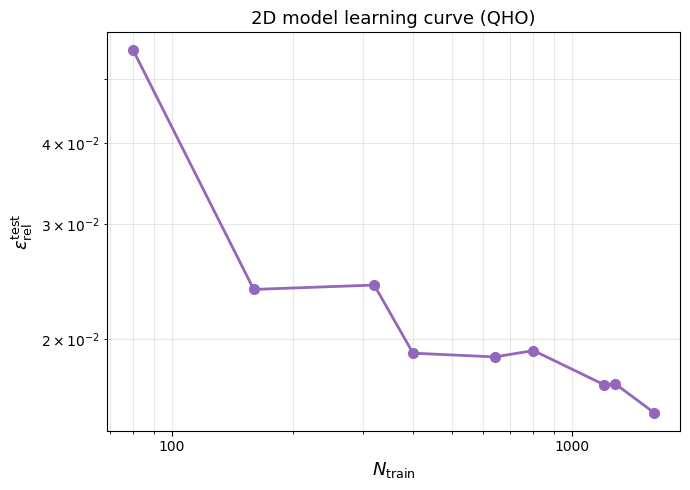

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(qho_ntrain, qho_rel, 'o-', color='tab:purple', lw=2, ms=7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$N_{\mathrm{train}}$', fontsize=13)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$', fontsize=13)
ax.set_title(r'2D model learning curve (QHO)', fontsize=13)
ax.grid(True, alpha=0.3, which='both')
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
from google.colab import files
plt.savefig('2D-QHO-learning-curve.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-QHO-learning-curve.pdf')


## Anharmonic Potentials: Shape Predictions

For the quartic and Morse potentials, only the full-data prediction quality is shown. All error metrics are $\varepsilon_{\mathrm{rel}}^{\mathrm{test}}$.

In [10]:
print("=== Quartic ===")
quartic_model, _, _, _, quartic_info = prepare_and_train(datasets['Quartic'], 'Quartic')
print("\n=== Morse ===")
morse_model, _, _, _, morse_info = prepare_and_train(datasets['Morse'], 'Morse')

=== Quartic ===
  Quartic     5%: n=  77  ε_rel^test=0.0623
  Quartic    10%: n= 154  ε_rel^test=0.0526
  Quartic    20%: n= 308  ε_rel^test=0.0440
  Quartic    25%: n= 385  ε_rel^test=0.0419
  Quartic    40%: n= 616  ε_rel^test=0.0275
  Quartic    50%: n= 770  ε_rel^test=0.0414
  Quartic    75%: n=1155  ε_rel^test=0.0242
  Quartic    80%: n=1232  ε_rel^test=0.0183
  Quartic   100%: n=1540  ε_rel^test=0.0178

=== Morse ===
  Morse     5%: n=  73  ε_rel^test=0.1055
  Morse    10%: n= 146  ε_rel^test=0.0913
  Morse    20%: n= 292  ε_rel^test=0.0564
  Morse    25%: n= 365  ε_rel^test=0.0467
  Morse    40%: n= 584  ε_rel^test=0.0447
  Morse    50%: n= 730  ε_rel^test=0.0459
  Morse    75%: n=1095  ε_rel^test=0.0385
  Morse    80%: n=1168  ε_rel^test=0.0468
  Morse   100%: n=1460  ε_rel^test=0.0479


### Quartic

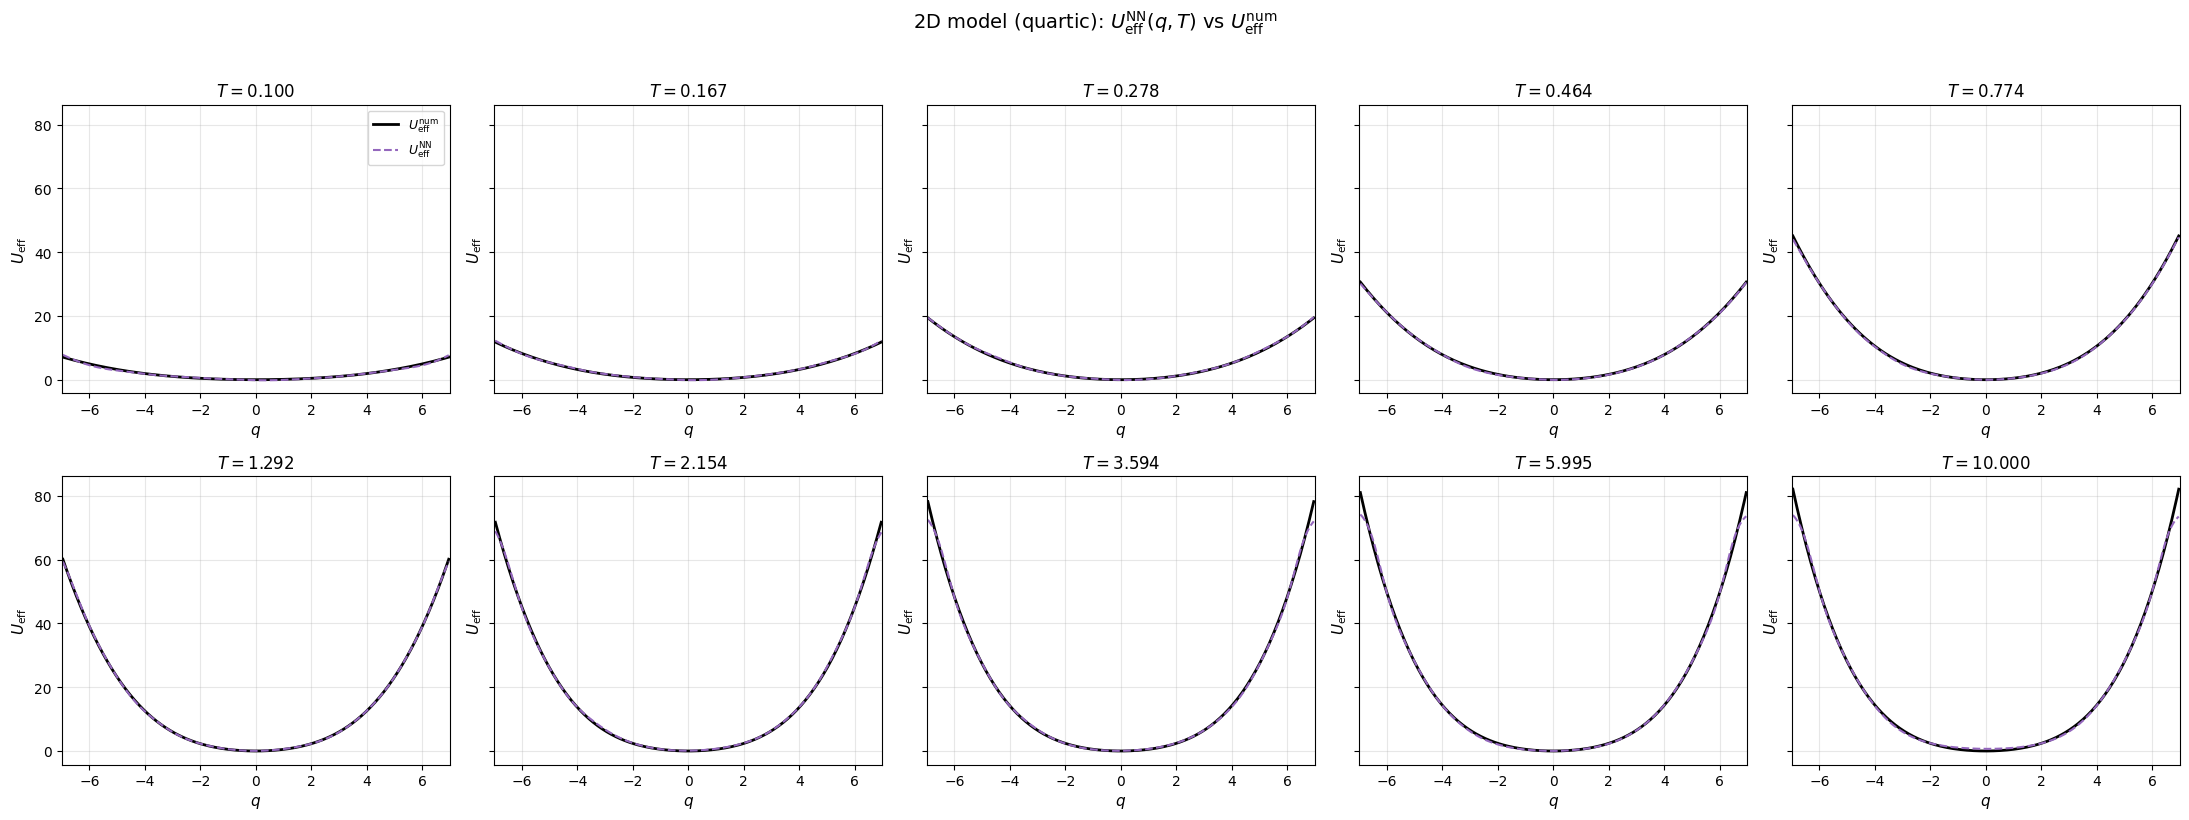

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
quartic_model.eval()
q_dense = np.linspace(quartic_info['q_grid'].min(), quartic_info['q_grid'].max(), 500)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    X_p = np.column_stack([q_dense, np.full_like(q_dense, T)])
    with torch.no_grad():
        y_pred = quartic_model(torch.tensor(X_p, dtype=torch.float32)).numpy().flatten()
    ax.plot(quartic_info['q_grid'], quartic_info['U_eff'][idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense, y_pred, '--', lw=1.5, color='tab:purple', label=r'$U_{\mathrm{eff}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.set_xlim(-7, 7)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'2D model (quartic): $U_{\mathrm{eff}}^{\mathrm{NN}}(q,T)$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$',
             fontsize=14, y=1.02)
plt.tight_layout()
from google.colab import files
plt.savefig('2D-quartic-predictions.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-quartic-predictions.pdf')

### Morse

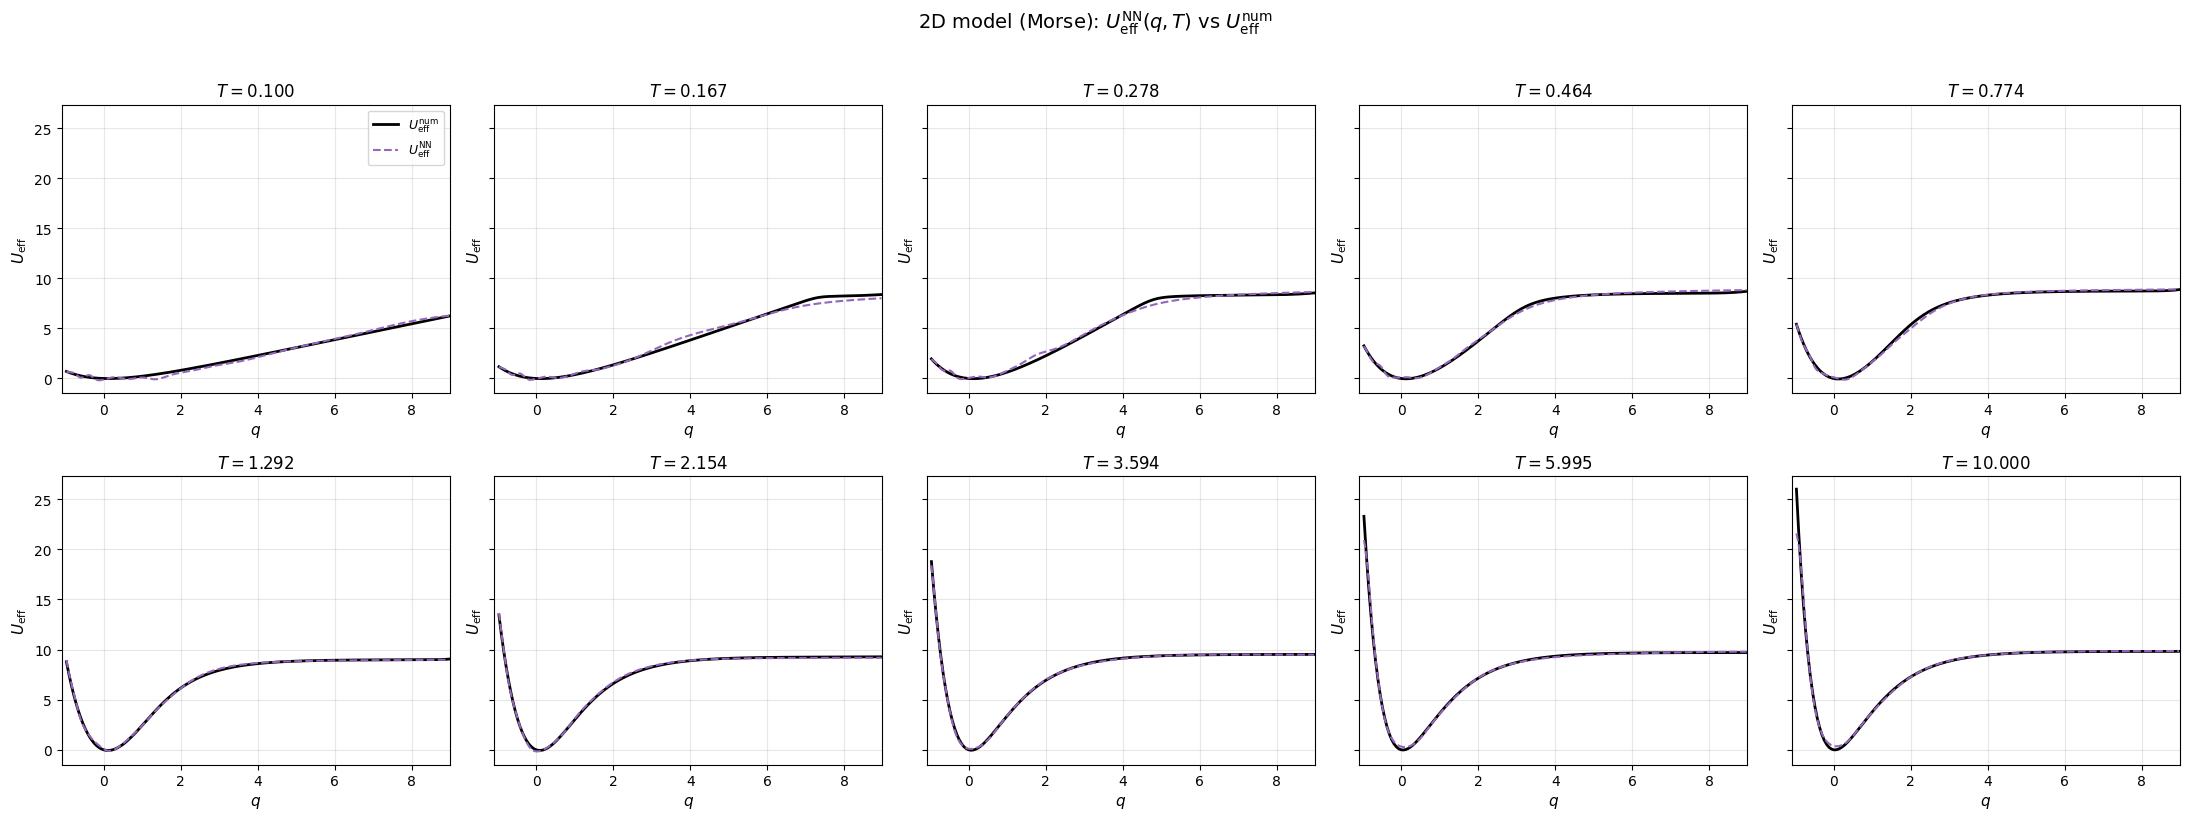

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
morse_model.eval()
q_dense = np.linspace(morse_info['q_grid'].min(), morse_info['q_grid'].max(), 500)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    X_p = np.column_stack([q_dense, np.full_like(q_dense, T)])
    with torch.no_grad():
        y_pred = morse_model(torch.tensor(X_p, dtype=torch.float32)).numpy().flatten()
    ax.plot(morse_info['q_grid'], morse_info['U_eff'][idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense, y_pred, '--', lw=1.5, color='tab:purple', label=r'$U_{\mathrm{eff}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    ax.set_title(f'$T = {T:.3f}$', fontsize=12)
    ax.set_xlim(-1.1, 9)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'2D model (Morse): $U_{\mathrm{eff}}^{\mathrm{NN}}(q,T)$ vs $U_{\mathrm{eff}}^{\mathrm{num}}$',
             fontsize=14, y=1.02)
plt.tight_layout()
from google.colab import files
plt.savefig('2D-morse-predictions.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-morse-predictions.pdf')

## Temperature Extrapolation for the QHO

The temperature extrapolation ability of the multi-temperature model is tested. The motivation stems from training on computationally cheap high-temperature data and predict the effective potential at low temperatures where, for more complex practical applications PIMD simulations will be expensive. Here the black-box 2D model is trained only on the 5 temperatures satisfying $T \geq 1$ and evaluated at all 10 temperatures. The low-$T$ regime ($T < 1$) is entirely unseen during training.

This is tested on the QHO. Any failure is attributable to the model rather than the data.

In [13]:
ds = datasets['QHO']
q_grid, U_eff, sigma_U, n_pos = ds['q_grid'], ds['U_eff'], ds['sigma_U'], ds['n_pos']

high_T_mask = temperatures >= 1.0
low_T_mask  = temperatures < 1.0
print(f"Training temperatures (T >= 1):  {temperatures[high_T_mask]}")
print(f"Extrapolation temperatures (T < 1): {temperatures[low_T_mask]}")

# data splits — same held-out positions
rng      = np.random.default_rng(seed=seed)
idx_shuf = rng.permutation(n_pos)
test_pos = set(idx_shuf[:n_test_per_T])
val_pos  = set(idx_shuf[n_test_per_T:n_test_per_T + n_val_per_T])

# full arrays for evaluation at all T
all_q_full = np.tile(q_grid, n_temperatures)
all_T_full = np.repeat(temperatures, n_pos)
all_U_full = U_eff.flatten()
j_full     = np.tile(np.arange(n_pos), n_temperatures)
is_test_full = np.isin(j_full, list(test_pos))
X_all_full   = np.column_stack([all_q_full, all_T_full])

# training arrays: high-T only
train_T_idx = np.where(high_T_mask)[0]
all_q_ht = np.tile(q_grid, len(train_T_idx))
all_T_ht = np.repeat(temperatures[train_T_idx], n_pos)
all_U_ht = U_eff[train_T_idx].flatten()
j_ht     = np.tile(np.arange(n_pos), len(train_T_idx))

is_test_ht  = np.isin(j_ht, list(test_pos))
is_val_ht   = np.isin(j_ht, list(val_pos))
is_train_ht = ~is_test_ht & ~is_val_ht

X_ht = np.column_stack([all_q_ht, all_T_ht])
Xv_e = torch.tensor(X_ht[is_val_ht],                     dtype=torch.float32)
yv_e = torch.tensor(all_U_ht[is_val_ht].reshape(-1, 1),  dtype=torch.float32)

X_tr_e = X_ht[is_train_ht]
y_tr_e = all_U_ht[is_train_ht].reshape(-1, 1)
shuf_e = np.random.default_rng(seed=seed).permutation(len(X_tr_e))

Xt_e = torch.tensor(X_tr_e[shuf_e], dtype=torch.float32)
yt_e = torch.tensor(y_tr_e[shuf_e], dtype=torch.float32)

extrap_model = build_model(hidden_dims)
extrap_model = train_2d(extrap_model, Xt_e, yt_e, Xv_e, yv_e, epochs, lr)
print("Extrapolation model trained.")

Training temperatures (T >= 1):  [ 1.29154967  2.15443469  3.59381366  5.9948425  10.        ]
Extrapolation temperatures (T < 1): [0.1        0.16681005 0.27825594 0.46415888 0.77426368]
Extrapolation model trained.


### Extrapolation Predictions

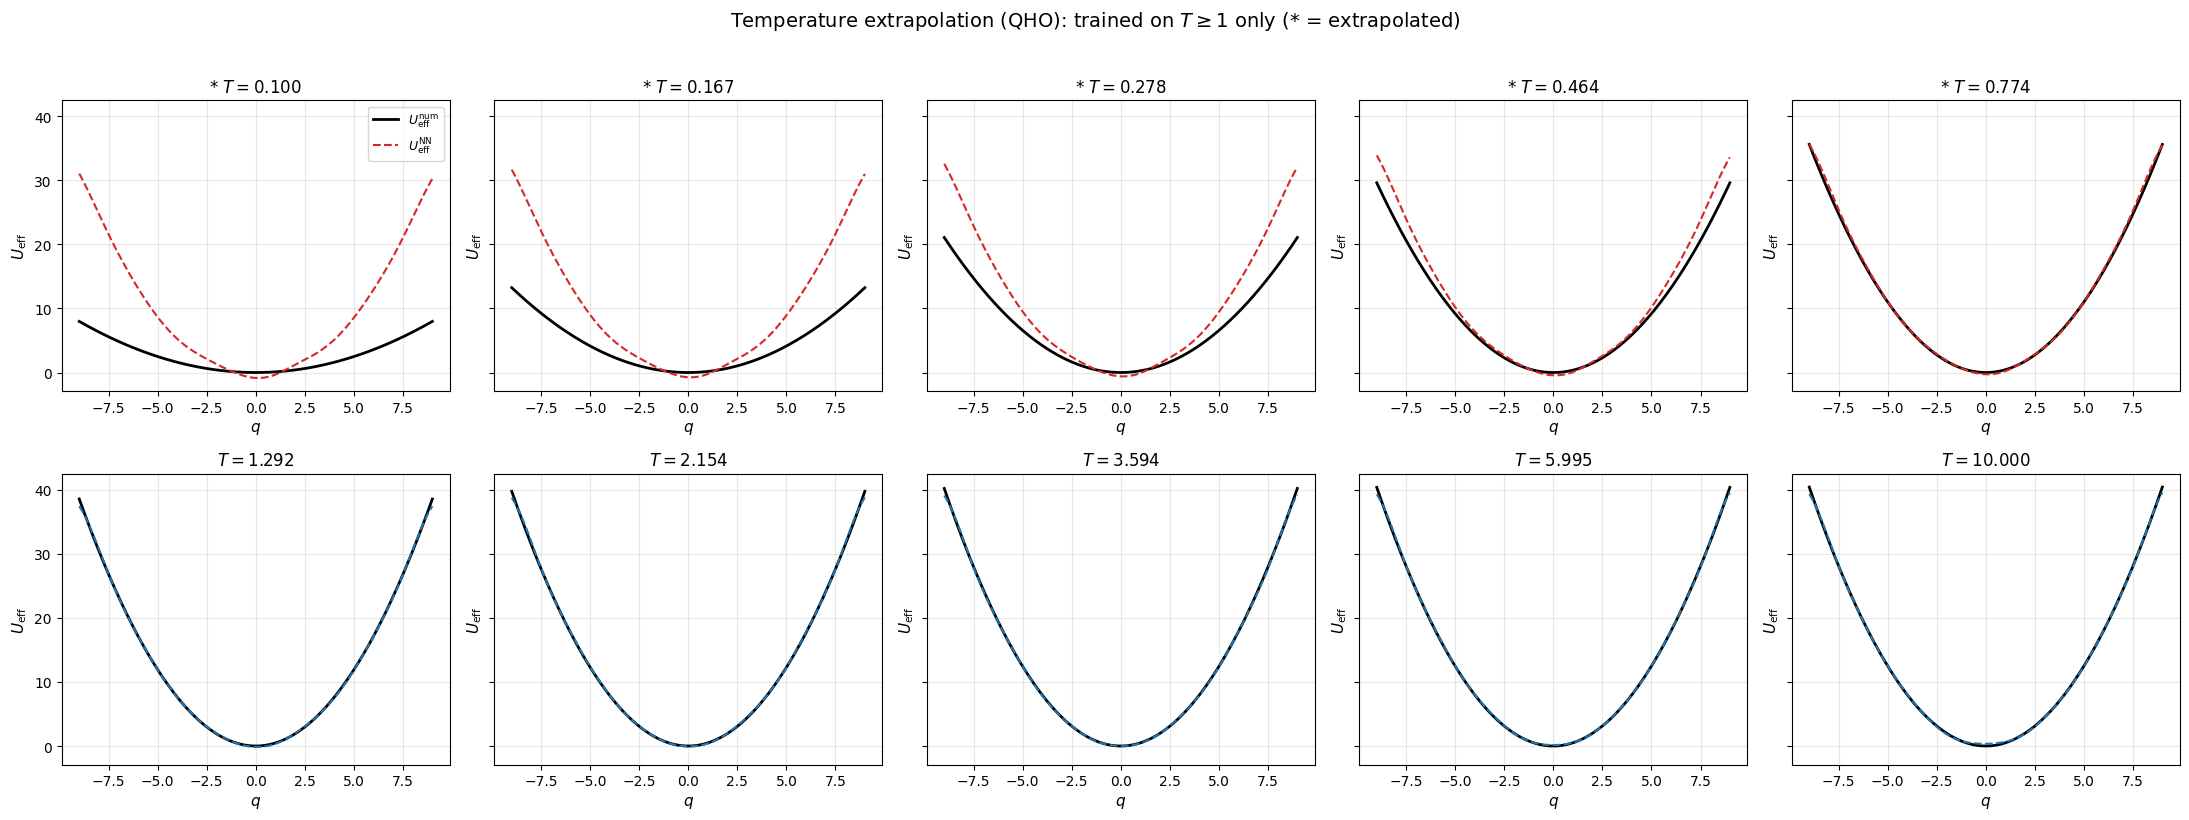

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
extrap_model.eval()
q_dense = np.linspace(q_grid.min(), q_grid.max(), 500)

for idx, ax in enumerate(axes.flatten()):
    T = temperatures[idx]
    X_p = np.column_stack([q_dense, np.full_like(q_dense, T)])
    with torch.no_grad():
        y_pred = extrap_model(torch.tensor(X_p, dtype=torch.float32)).numpy().flatten()
    ax.plot(q_grid, U_eff[idx], 'k-', lw=2, label=r'$U_{\mathrm{eff}}^{\mathrm{num}}$')
    ax.plot(q_dense, y_pred, '--', lw=1.5,
            color='tab:red' if T < 1.0 else 'tab:blue',
            label=r'$U_{\mathrm{eff}}^{\mathrm{NN}}$')
    ax.set_xlabel(r'$q$', fontsize=11)
    ax.set_ylabel(r'$U_{\mathrm{eff}}$', fontsize=11)
    title_prefix = '* ' if T < 1.0 else ''
    ax.set_title(f'{title_prefix}$T = {T:.3f}$', fontsize=12)
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=9)

fig.suptitle(r'Temperature extrapolation (QHO): trained on $T \geq 1$ only (* = extrapolated)',
             fontsize=14, y=1.02)
plt.tight_layout()
from google.colab import files
plt.savefig('2D-extrap-predictions.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-extrap-predictions.pdf')

### Extrapolation Error

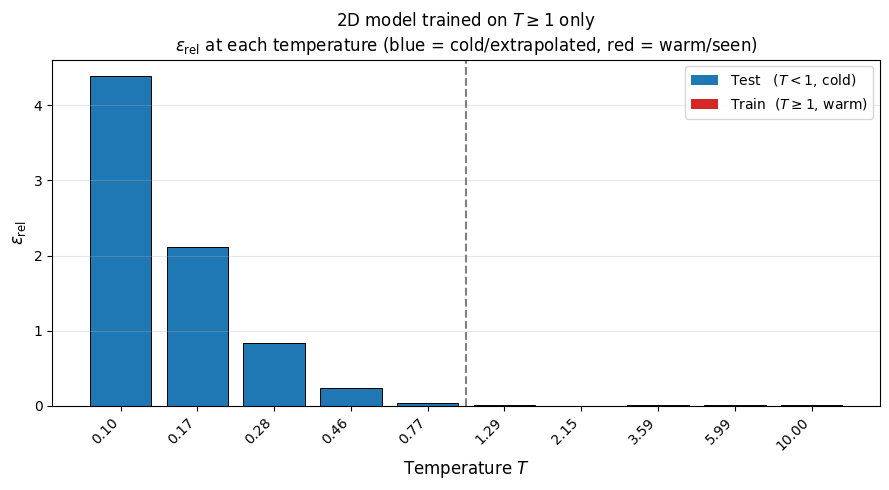

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

         T    ε_rel^test           regime
    0.1000      4.388831    extrapolation
    0.1668      2.112039    extrapolation
    0.2783      0.834018    extrapolation
    0.4642      0.236108    extrapolation
    0.7743      0.032773    extrapolation
    1.2915      0.005791    interpolation
    2.1544      0.005065    interpolation
    3.5938      0.009270    interpolation
    5.9948      0.007187    interpolation
   10.0000      0.010058    interpolation


In [15]:
extrap_model.eval()
extrap_per_T_rmse = np.zeros(n_temperatures)
for t_idx, T in enumerate(temperatures):
    mask = is_test_full & (all_T_full == T)
    Xt_ = torch.tensor(X_all_full[mask], dtype=torch.float32)
    yt_ = all_U_full[mask].reshape(-1, 1)
    extrap_per_T_rmse[t_idx] = compute_rmse(extrap_model, Xt_, yt_)

extrap_per_T_sigma = np.array([
    np.std(all_U_full[is_test_full & (all_T_full == T)])
    for T in temperatures
])
extrap_per_T_rel_test = extrap_per_T_rmse / extrap_per_T_sigma

from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

colors_bar = ['tab:blue' if T < 1.0 else 'tab:red' for T in temperatures]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(n_temperatures), extrap_per_T_rel_test, color=colors_bar, edgecolor='k', linewidth=0.7)
ax.set_xticks(range(n_temperatures))
ax.set_xticklabels([f'{T:.2f}' for T in temperatures], rotation=45, ha='right')
ax.set_xlabel(r'Temperature $T$', fontsize=12)
ax.set_ylabel(r'$\varepsilon_{\mathrm{rel}}$', fontsize=12)
ax.set_title(
    r'2D model trained on $T \geq 1$ only' + '\n' +
    r'$\varepsilon_{\mathrm{rel}}$ at each temperature (blue = cold/extrapolated, red = warm/seen)',
    fontsize=12)
ax.axvline(x=4.5, color='gray', ls='--', lw=1.5)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, alpha=0.3, axis='y')
legend_handles = [
    Patch(facecolor='tab:blue', label=r'Test   ($T < 1$, cold)'),
    Patch(facecolor='tab:red',  label=r'Train  ($T \geq 1$, warm)'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
from google.colab import files
plt.savefig('2D-extrap-error-per-T.pdf', bbox_inches='tight', dpi=150)
plt.show()
files.download('2D-extrap-error-per-T.pdf')

print(f"{'T':>10}  {'ε_rel^test':>12}  {'regime':>15}")
for T, e in zip(temperatures, extrap_per_T_rel_test):
    regime = 'extrapolation' if T < 1.0 else 'interpolation'
    print(f"{T:10.4f}  {e:12.6f}  {regime:>15}")